# Feature engineering diagrams (presentation)

**Run:** **Kernel → Restart kernel & Run All**, with the workspace folder **`ABR2synapse`** (same as other project notebooks — not the parent `Practicum` folder unless you `os.chdir`). The setup cell raises if `utils/nn_stage2_data.py` is missing.

The notebook picks one **Liberman** exemplar row for all figures. **Default:** **level ≥ 60 dB**, **frequency > 16 kHz**, valid **full_waveform** / **Peaks** / **Troughs**, preferring the **longest** stored waveform for clearer plots. **Override** in the second code cell: set **`PICK_LONG_INDEX`** *or* all three of **`PICK_ANIMAL_ID`**, **`PICK_FREQUENCY_KHZ`**, **`PICK_LEVEL_DB`**. After selection, that cell plots the **full 0–17 ms waveform** with Peak/Trough markers and the **0–8 ms** band so you can confirm the row before running later figures.

Static visuals aligned with **`utils/feature_extraction.py`** (Liberman pipeline in `utils/data_loader.py`): **amplitude**, **`slope`** (= **`slope_from_amplitude_distance`**: **−amplitude / distance** in µV/ms, same **`Amplitude`** and **`Distance`** as the tables), **`total_variance`** over the **Wave I interval** from `find_waveI`, **`distance`** (= peak→trough **latency** on 0–17 ms), and **curvature** at Peak I / Trough I.

**Data:** Liberman **`orig_lib`** (`load_nn_stage2_data`).
Run with cwd **`ABR2synapse`**.

Exports → **`figures/presentation/features/`** — includes wide/long tables, **`feat_amplitude.png`** / **`feat_distance.png`**, slope, variance, curvature PNGs (absolute path printed when the setup cell runs).


In [9]:
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Figures go under cwd — must be the ABR2synapse folder (same as other notebooks).
_CWD = Path.cwd().resolve()
if not (_CWD / "utils" / "nn_stage2_data.py").is_file():
    raise RuntimeError(
        "Wrong working directory for this notebook.\n"
        f"  cwd = {_CWD}\n"
        "Open/run from the **ABR2synapse** folder (must contain utils/nn_stage2_data.py).\n"
        "In Cursor/VS Code: File → Open Folder → …/Practicum/ABR2synapse, then restart kernel & Run All.\n"
        "Or insert one cell above: import os; os.chdir(\"…/ABR2synapse\")"
    )

from utils.benchmark_metrics import apply_slide_rcparams
from utils.feature_extraction import (
    calculate_curvature as fe_curvature,
    calculate_distance as fe_distance,
    calculate_variance as fe_variance,
    find_waveI,
    slope_from_amplitude_distance,
)
from utils.nn_stage2_data import load_nn_stage2_data

apply_slide_rcparams()
FIG = _CWD / "figures" / "presentation" / "features"
FIG.mkdir(parents=True, exist_ok=True)
print("Saving PNGs under:", FIG)


Saving PNGs under: /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features


Exemplar row — [manual key (WPZ145, 22.6 kHz, 70.0 dB SPL)] animal=WPZ145, 22.6 kHz, 70.0 dB SPL


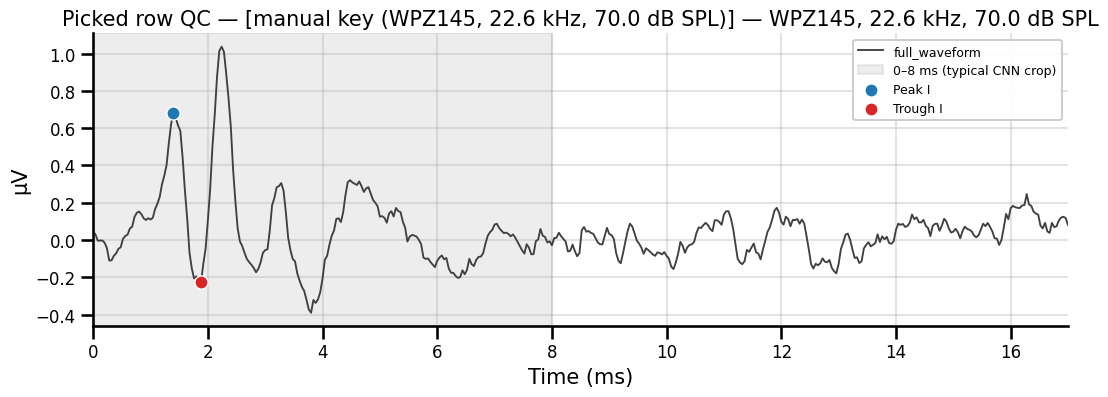

In [10]:
data = load_nn_stage2_data()
lib = data.orig_lib.copy()

# --- Exemplar row (edit to override automatic pick) ---
# Option A — leave everything ``None`` for automatic pick (high SPL / high freq / longest waveform).
# Option B — set ``PICK_LONG_INDEX`` to an integer row of ``lib.reset_index(drop=True)`` (wins over C).
# Option C — set all three key fields (animal, frequency kHz, SPL dB); floats use approximate match.
PICK_LONG_INDEX = None  # e.g. 124
PICK_ANIMAL_ID = "WPZ145"  # e.g. "WPZ145"
PICK_FREQUENCY_KHZ = 22.6  # e.g. 45.2
PICK_LEVEL_DB = 70.0  # e.g. 70.0


def _pick_liberman_row(df: pd.DataFrame) -> pd.Series:
    """Prefer **high SPL (≥60 dB)** and **high frequency (>16 kHz)** with valid waveform picks."""
    need = {"full_waveform", "Peaks", "Troughs", "level", "frequency"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(
            "orig_lib needs columns "
            + ", ".join(sorted(need))
            + " — pull latest nn_stage2_data (Peaks/Troughs retained)."
        )
    lev = df["level"].astype(float)
    fq = df["frequency"].astype(float)
    ok = (
        df["full_waveform"].notna()
        & df["Peaks"].notna()
        & df["Troughs"].notna()
        & (lev >= 60)
        & (fq > 16)
    )
    sub = df.loc[ok].copy()
    if sub.empty:
        raise ValueError(
            "No rows with level≥60 dB, frequency>16 kHz, and valid full_waveform/Peaks/Troughs. "
            "Adjust thresholds in _pick_liberman_row or check orig_lib."
        )
    lens = sub["full_waveform"].apply(lambda w: len(np.asarray(w).ravel()))
    idx = lens.idxmax()
    picked = sub.loc[idx]
    if isinstance(picked, pd.DataFrame):
        picked = picked.iloc[0]
    return picked.copy()


def _pick_liberman_row_by_key(
    df: pd.DataFrame,
    animal_id: str,
    frequency_khz: float,
    level_db: float,
) -> pd.Series:
    """Exact Liberman long row by animal × frequency × SPL (floats matched with ``np.isclose``)."""
    need = {"full_waveform", "Peaks", "Troughs", "level", "frequency", "animal_id"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError("orig_lib missing columns: " + ", ".join(sorted(missing)))
    aid = str(animal_id).strip()
    fq = float(frequency_khz)
    lv = float(level_db)
    fa = df["frequency"].astype(float)
    la = df["level"].astype(float)
    aa = df["animal_id"].astype(str).str.strip()
    m = (
        aa.eq(aid)
        & np.isclose(fa, fq, rtol=0.0, atol=1e-4)
        & np.isclose(la, lv, rtol=0.0, atol=1e-4)
    )
    sub = df.loc[m].copy()
    if sub.empty:
        raise ValueError(
            f"No Liberman row for animal_id={aid!r}, frequency_kHz={fq}, level_dB={lv}. "
            "Check spelling / SPL / kHz or try PICK_LONG_INDEX."
        )
    if len(sub) > 1:
        sub = sub.iloc[[0]]
    return sub.iloc[0].copy()


def resolve_exemplar_row(df: pd.DataFrame) -> tuple[pd.Series, str]:
    """Return ``(row, description)`` according to ``PICK_*`` constants."""
    if PICK_LONG_INDEX is not None:
        flat = df.reset_index(drop=True)
        i = int(PICK_LONG_INDEX)
        if i < 0 or i >= len(flat):
            raise IndexError(
                f"PICK_LONG_INDEX={i} out of range for orig_lib with {len(flat)} rows "
                "(after reset_index(drop=True))."
            )
        return flat.iloc[i].copy(), f"manual row index {i}"

    key_set = (
        PICK_ANIMAL_ID is not None
        or PICK_FREQUENCY_KHZ is not None
        or PICK_LEVEL_DB is not None
    )
    if key_set:
        if (
            PICK_ANIMAL_ID is None
            or PICK_FREQUENCY_KHZ is None
            or PICK_LEVEL_DB is None
        ):
            raise ValueError(
                "Manual key selection requires **all three**: PICK_ANIMAL_ID, "
                "PICK_FREQUENCY_KHZ, PICK_LEVEL_DB (or leave all three None)."
            )
        row = _pick_liberman_row_by_key(
            df, PICK_ANIMAL_ID, float(PICK_FREQUENCY_KHZ), float(PICK_LEVEL_DB)
        )
        return row, (
            f"manual key ({PICK_ANIMAL_ID}, {float(PICK_FREQUENCY_KHZ)} kHz, "
            f"{float(PICK_LEVEL_DB)} dB SPL)"
        )

    return _pick_liberman_row(df), "automatic (≥60 dB, >16 kHz, longest waveform)"


def as_scalar(val):
    """Coerce a single cell that may arrive as Series (duplicate labels) to a scalar."""
    while isinstance(val, pd.Series):
        val = val.iloc[0]
    return val


row, _row_source = resolve_exemplar_row(lib)


def lib_time_axis(wave: np.ndarray) -> np.ndarray:
    wave = np.asarray(wave).ravel()
    return np.linspace(0.0, 17.0, len(wave))


def peaks_troughs_arrays(r: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    pk = np.asarray(r["Peaks"], dtype=int)
    tr = np.asarray(r["Troughs"], dtype=int)
    return pk, tr


def plot_style(ax):
    ax.grid(True, alpha=0.35)
    sns.despine(ax=ax)


print(
    "Exemplar row —",
    f"[{_row_source}]",
    f"animal={as_scalar(row['animal_id'])},",
    f"{as_scalar(row['frequency'])} kHz,",
    f"{as_scalar(row['level'])} dB SPL",
)

# --- Quick visual QC: full 0–17 ms Liberman trace (adjust PICK_* above if this looks wrong)
wf_qc = np.asarray(row["full_waveform"], dtype=float).ravel()
x_qc = lib_time_axis(wf_qc)
pk_qc, tr_qc = peaks_troughs_arrays(row)

fig_qc, ax_qc = plt.subplots(figsize=(11, 4.2))
ax_qc.plot(x_qc, wf_qc, color="0.25", lw=1.35, label="full_waveform")
ax_qc.axvspan(
    0.0, 8.0, alpha=0.12, color="0.45", zorder=0, label="0–8 ms (typical CNN crop)"
)
ax_qc.scatter(
    [float(x_qc[pk_qc[0]])],
    [float(wf_qc[pk_qc[0]])],
    s=90,
    zorder=6,
    c="C0",
    edgecolors="white",
    linewidths=1,
    label="Peak I",
)
ax_qc.scatter(
    [float(x_qc[tr_qc[0]])],
    [float(wf_qc[tr_qc[0]])],
    s=90,
    zorder=6,
    c="C3",
    edgecolors="white",
    linewidths=1,
    label="Trough I",
)

ax_qc.set_xlim(0.0, 17.0)
ax_qc.set_xlabel("Time (ms)")
ax_qc.set_ylabel("µV")
ax_qc.set_title(
    f"Picked row QC — [{_row_source}] — "
    f"{as_scalar(row['animal_id'])}, {as_scalar(row['frequency'])} kHz, "
    f"{as_scalar(row['level'])} dB SPL"
)
plot_style(ax_qc)
ax_qc.legend(loc="upper right", fontsize=9, framealpha=0.95)
fig_qc.tight_layout()
plt.show()

## Wide vs long format

- **Long:** one row per **animal × frequency × SPL** — Liberman `orig_lib`.
- **Wide:** one row per **animal × frequency** with **`amplitude_<level>`** columns — `reformatted_orig` (Liberman pivot).

Figure: same **Liberman** animal × frequency as `row` below.


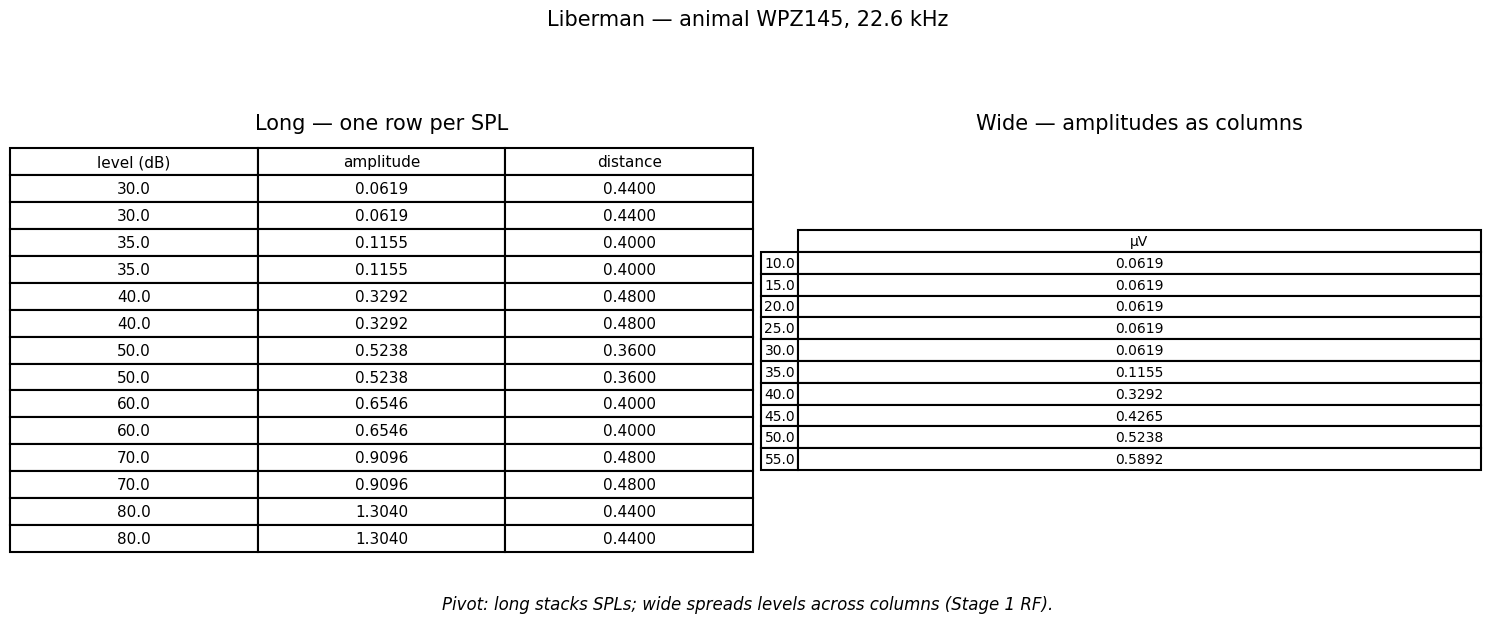

In [11]:
rfo = data.reformatted_orig
aid = as_scalar(row["animal_id"])
fq = as_scalar(row["frequency"])

long_demo = (
    lib.loc[(lib["animal_id"] == aid) & (lib["frequency"] == fq)]
    .sort_values("level")[["level", "amplitude", "distance"]]
    .iloc[:14]
    .reset_index(drop=True)
)

wide_row = rfo.loc[(rfo["animal_id"] == aid) & (rfo["frequency"] == fq)].iloc[:1]


def _spl_key(col: str) -> float:
    return float(str(col).split("_", 1)[1])


amp_cols = sorted(
    [c for c in rfo.columns if str(c).startswith("amplitude_")],
    key=_spl_key,
)
step = max(1, len(amp_cols) // 10)
wide_amp = wide_row[amp_cols[::step][:10]]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].axis("off")
axes[0].set_title(
    "Long — one row per SPL",
    fontsize=15,
    pad=14,
)
cell_text0 = []
for _, r in long_demo.iterrows():
    cell_text0.append(
        [f"{r['level']:.1f}", f"{r['amplitude']:.4f}", f"{r['distance']:.4f}"]
    )
tbl0 = axes[0].table(
    cellText=cell_text0,
    colLabels=["level (dB)", "amplitude", "distance"],
    loc="center",
    cellLoc="center",
)
tbl0.auto_set_font_size(False)
tbl0.set_fontsize(11)
tbl0.scale(1.25, 1.85)

axes[1].axis("off")
axes[1].set_title(
    "Wide — amplitudes as columns",
    fontsize=15,
    pad=14,
)
wt = wide_amp.T
wt.columns = ["amplitude"]
row_lab = [c.replace("amplitude_", "") for c in wt.index]
cell_text1 = [[f"{v:.4f}"] for v in wt["amplitude"].values]
tbl1 = axes[1].table(
    cellText=cell_text1,
    rowLabels=row_lab,
    colLabels=["µV"],
    loc="center",
    cellLoc="center",
)
tbl1.auto_set_font_size(False)
tbl1.set_fontsize(10)
tbl1.scale(1.15, 1.5)

fig.suptitle(
    f"Liberman — animal {aid}, {fq} kHz",
    fontsize=15,
    y=1.02,
)
fig.text(
    0.5,
    0.02,
    "Pivot: long stacks SPLs; wide spreads levels across columns (Stage 1 RF).",
    ha="center",
    fontsize=12,
    style="italic",
)
fig.subplots_adjust(bottom=0.14)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.savefig(FIG / "feat_wide_vs_long.png", dpi=300, bbox_inches="tight")
plt.show()

## 1 — Amplitude & distance (`feature_extraction`)

Two exports: **`feat_amplitude.png`** (waveform **0–8 ms only**) and **`feat_distance.png`** (segment long enough to include peak & trough).

- **Amplitude:** horizontal **baseline** `(wave[0]+wave[-1])/2` (same spirit as crossings in `feature_extraction`), **vertical** segments from baseline to peak and trough, a **shaded µV band** between peak & trough voltages between those times, and a **vertical double-arrow** spanning that band — labeled with stored **`amplitude`** (and |ΔµV| for the drawn segment).
- **Distance:** shaded **time band** (**`axvspan`**) between peak and trough times; **horizontal** `<->` arrow placed **high** in the panel (clear of axis/ticks) marking **Δt ms**.


Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_amplitude.png


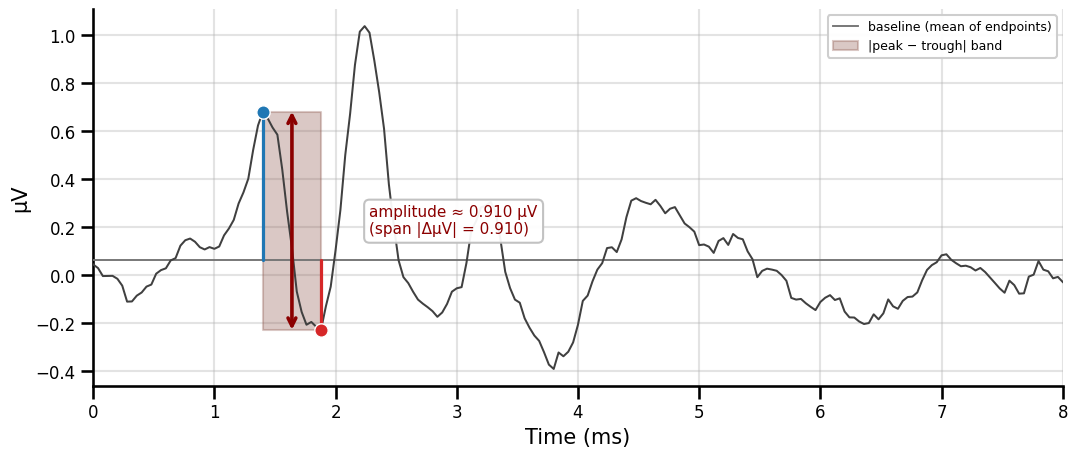

Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_distance.png


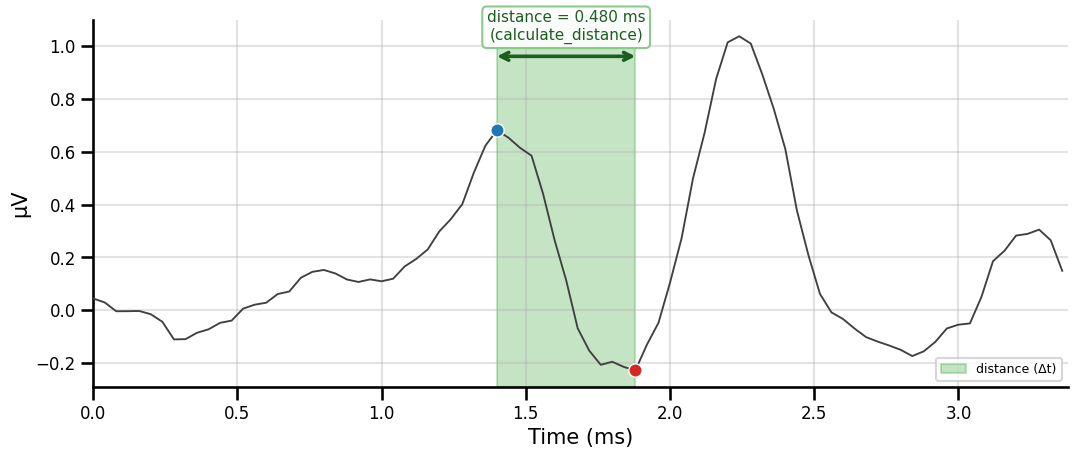

In [12]:
wf_full = np.asarray(row["full_waveform"], dtype=float).ravel()
x_full = lib_time_axis(wf_full)
peaks, troughs = peaks_troughs_arrays(row)
pk_i, tr_i = int(peaks[0]), int(troughs[0])
t_pk, t_tr = float(x_full[pk_i]), float(x_full[tr_i])
dist_ms = float(fe_distance(wf_full, peaks, troughs))
amp_tbl = float(row["amplitude"])

cut_ms = 8.0
m8 = x_full <= cut_ms
xa, wa = x_full[m8], wf_full[m8]

v_pk = float(wf_full[pk_i])
v_tr = float(wf_full[tr_i])
baseline = float((wf_full[0] + wf_full[-1]) / 2)

fig_a, ax_a = plt.subplots(figsize=(11, 4.8))
ax_a.plot(xa, wa, color="0.25", lw=1.45, zorder=5)
ax_a.axhline(
    baseline,
    color="0.45",
    ls="-",
    lw=1.35,
    label="baseline (mean of endpoints)",
    zorder=4,
)

ax_a.scatter([t_pk], [v_pk], s=92, zorder=8, c="C0", edgecolors="white", linewidths=1)
ax_a.scatter([t_tr], [v_tr], s=92, zorder=8, c="C3", edgecolors="white", linewidths=1)

if t_pk <= cut_ms and t_tr <= cut_ms:
    ax_a.plot(
        [t_pk, t_pk],
        [baseline, v_pk],
        color="C0",
        lw=2.3,
        solid_capstyle="round",
        zorder=7,
    )
    ax_a.plot(
        [t_tr, t_tr],
        [baseline, v_tr],
        color="C3",
        lw=2.3,
        solid_capstyle="round",
        zorder=7,
    )

    band_lo = min(v_pk, v_tr)
    band_hi = max(v_pk, v_tr)
    x_lo, x_hi = sorted([t_pk, t_tr])
    xx_band = np.linspace(x_lo, x_hi, 80)
    ax_a.fill_between(
        xx_band,
        band_lo,
        band_hi,
        alpha=0.32,
        color="C5",
        zorder=2,
        label="|peak − trough| band",
    )

    x_mid = (t_pk + t_tr) / 2
    ax_a.annotate(
        "",
        xy=(x_mid, band_hi),
        xytext=(x_mid, band_lo),
        arrowprops=dict(
            arrowstyle="<->", color="darkred", lw=2.6, shrinkA=0, shrinkB=0
        ),
        zorder=9,
    )
    amp_span_uv = abs(v_pk - v_tr)
    ax_a.text(
        min(cut_ms * 0.98, x_mid + (cut_ms * 0.08)),
        (band_hi + band_lo) / 2,
        f"amplitude ≈ {amp_tbl:.3f} µV\n(span |ΔµV| = {amp_span_uv:.3f})",
        fontsize=11,
        ha="left",
        va="center",
        color="darkred",
        bbox=dict(
            boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.94
        ),
        zorder=10,
    )
else:
    ax_a.text(
        0.02,
        0.97,
        f"Stored amplitude = {amp_tbl:.4f} µV\n(peak/trough not both ≤ {cut_ms} ms — schematic omitted.)",
        transform=ax_a.transAxes,
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.94),
    )

ax_a.set_xlim(0, cut_ms)
ax_a.set_xlabel("Time (ms)")
ax_a.set_ylabel("µV")
ax_a.legend(loc="upper right", fontsize=9, framealpha=0.95)
plot_style(ax_a)
fig_a.tight_layout()
fig_a.savefig(FIG / "feat_amplitude.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_amplitude.png").resolve())
plt.show()

xmax_d = float(min(17.0, max(t_pk, t_tr) + 1.5))
md = x_full <= xmax_d

fig_d, ax_d = plt.subplots(figsize=(11, 4.8))
x_plot = x_full[md]
y_plot = wf_full[md]

ax_d.axvspan(
    min(t_pk, t_tr),
    max(t_pk, t_tr),
    alpha=0.28,
    color="C2",
    zorder=1,
    label="distance (Δt)",
)

ax_d.plot(x_plot, y_plot, color="0.25", lw=1.35, zorder=4)
ax_d.scatter([t_pk], [v_pk], s=92, zorder=7, c="C0", edgecolors="white", linewidths=1)
ax_d.scatter([t_tr], [v_tr], s=92, zorder=7, c="C3", edgecolors="white", linewidths=1)

ylim = ax_d.get_ylim()
y_rng = ylim[1] - ylim[0]
yr = ylim[1] - 0.10 * y_rng

ax_d.annotate(
    "",
    xy=(max(t_pk, t_tr), yr),
    xytext=(min(t_pk, t_tr), yr),
    arrowprops=dict(
        arrowstyle="<->",
        color="#1b5e20",
        lw=2.6,
        shrinkA=0,
        shrinkB=0,
    ),
    zorder=6,
)
ax_d.text(
    (t_pk + t_tr) / 2,
    yr + 0.035 * y_rng,
    f"distance = {dist_ms:.3f} ms\n(calculate_distance)",
    ha="center",
    va="bottom",
    fontsize=11,
    color="#1b5e20",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92, edgecolor="#81c784"),
    zorder=8,
)

ax_d.set_xlim(0, xmax_d)
ax_d.set_xlabel("Time (ms)")
ax_d.set_ylabel("µV")
ax_d.legend(loc="lower right", fontsize=9)
plot_style(ax_d)
fig_d.tight_layout()
fig_d.savefig(FIG / "feat_distance.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_distance.png").resolve())
plt.show()

## 2 — Slope (`slope_from_amplitude_distance`)

Row-level **`slope`** = **−Amplitude / Distance** (µV/ms), matching **`utils.data_loader`**: same stored **`amplitude`** and **`distance`** (`calculate_distance` latency span) as in §1.

The figure shows the **Wave I window** from **`find_waveI`** and the **Peak I → Trough I** chord used to relate voltage span and Δt to that formula.

This is **not** amplitude-vs-SPL slope — that is **`Slope_all` / `Slope_high4`** from **`amplitude_vs_spl_slopes`** (aggregated across SPLs).


Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_waveform_slope.png


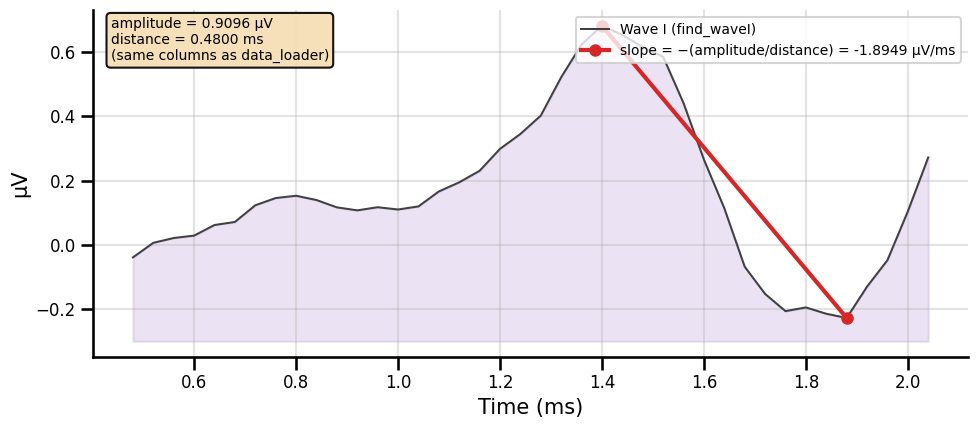

In [13]:
start, mid, end = find_waveI(wf_full, peaks, troughs)
x_lin = lib_time_axis(wf_full)
slope_val = float(slope_from_amplitude_distance(amp_tbl, dist_ms))

xs_seg = x_lin[start : end + 1]
wf_seg = wf_full[start : end + 1]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(xs_seg, wf_seg, color="0.25", lw=1.45, label="Wave I (find_waveI)")
if wf_seg.size:
    lo = float(wf_seg.min())
    hi = float(wf_seg.max())
    pad = 0.08 * (hi - lo if hi > lo else 1.0)
    ax.fill_between(xs_seg, lo - pad, wf_seg, alpha=0.18, color="C4")

ax.plot(
    [x_lin[pk_i], x_lin[tr_i]],
    [wf_full[pk_i], wf_full[tr_i]],
    color="C3",
    lw=3,
    marker="o",
    ms=8,
    label=f"slope = −(amplitude/distance) = {slope_val:.4f} µV/ms",
)

ax.text(
    0.02,
    0.98,
    f"amplitude = {amp_tbl:.4f} µV\n"
    f"distance = {dist_ms:.4f} ms\n"
    f"(same columns as data_loader)",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.92),
)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("µV")
ax.legend(loc="upper right", fontsize=10)
plot_style(ax)
fig.tight_layout()
fig.savefig(FIG / "feat_waveform_slope.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_waveform_slope.png").resolve())
plt.show()

## 3 — Total variance (`calculate_variance`)

Variance is computed on **`wave[start:end+1]`** after **`find_waveI`** — the **full Wave I segment** (`feature_extraction.calculate_variance`). The plot uses **milliseconds** on the x-axis for that **entire** segment.


Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_total_variance.png


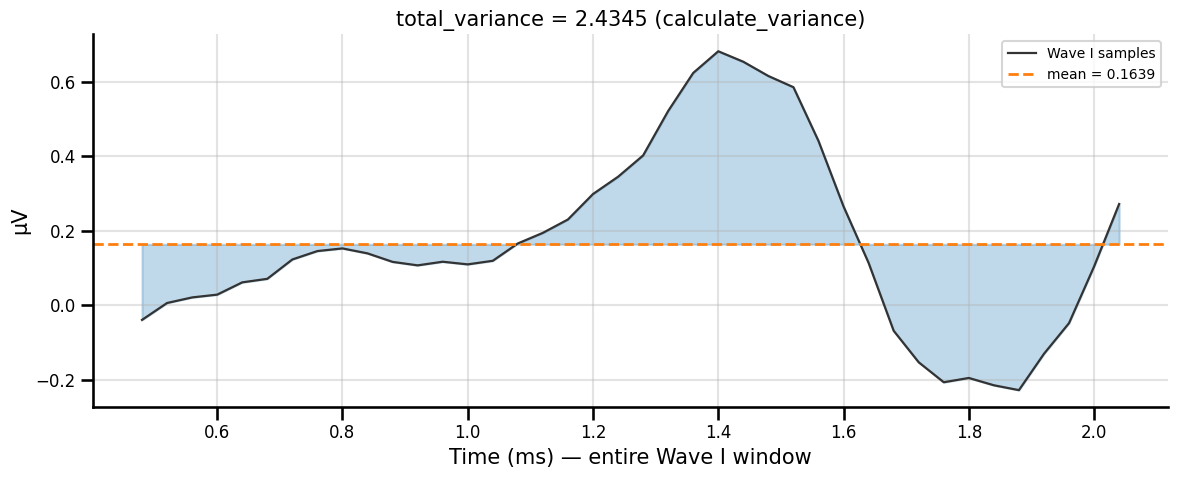

In [14]:
tv = float(fe_variance(wf_full, peaks, troughs))
start, mid, end = find_waveI(wf_full, peaks, troughs)
xs = x_full[start : end + 1]
seg = wf_full[start : end + 1]
mu = float(np.mean(seg))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(xs, seg, color="0.2", lw=1.6, label="Wave I samples")
ax.axhline(mu, color="C1", ls="--", lw=2, label=f"mean = {mu:.4f}")
ax.fill_between(xs, mu, seg, alpha=0.28, color="C0")
ax.set_xlabel("Time (ms) — entire Wave I window")
ax.set_ylabel("µV")
ax.set_title(f"total_variance = {tv:.4f} (calculate_variance)")
ax.legend(fontsize=10)
plot_style(ax)
fig.tight_layout()
fig.savefig(FIG / "feat_total_variance.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_total_variance.png").resolve())
plt.show()

## 4 — Peak curvature (Early / Central / Late)

**`calculate_curvature(wave, peaks[0])`** from **`feature_extraction`** (0–17 ms axis). Same construction as **`PeakIEarlyCurvature`** … **`PeakILateCurvature`.**


Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_peak_curvature.png


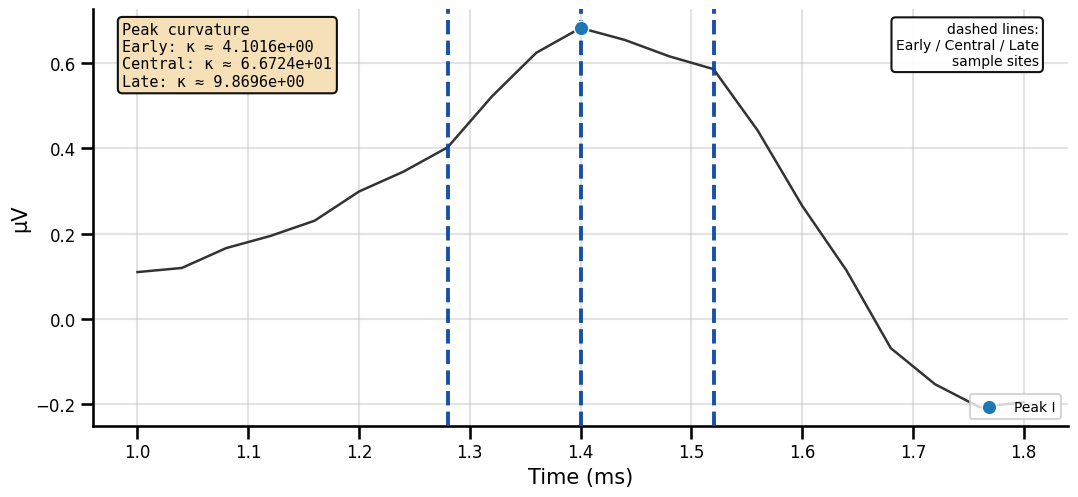

In [15]:
pk_i = int(peaks[0])
curv_vec = np.asarray(fe_curvature(wf_full, pk_i)).ravel()
labels = ["Early", "Central", "Late"]

idx_rng = range(pk_i - 10, pk_i + 11)
x_zoom = x_full[list(idx_rng)]
y_zoom = wf_full[list(idx_rng)]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(x_zoom, y_zoom, color="0.2", lw=1.8)
pts_x = x_full[pk_i - 3 : pk_i + 4 : 3]
for tx in pts_x:
    ax.axvline(
        tx,
        ls="--",
        lw=2.8,
        color="#0d47a1",
        alpha=0.95,
        zorder=3,
    )
ax.scatter(
    [x_full[pk_i]],
    [wf_full[pk_i]],
    s=110,
    zorder=6,
    c="C0",
    edgecolors="white",
    linewidths=1,
    label="Peak I",
)

summary_lines = [f"{lb}: κ ≈ {cv:.4e}" for lb, cv in zip(labels, curv_vec)]
summary = "Peak curvature\n" + "\n".join(summary_lines)

ax.text(
    0.03,
    0.97,
    summary,
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.94),
)

ax.text(
    0.97,
    0.97,
    "dashed lines:\nEarly / Central / Late\nsample sites",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92),
)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("µV")
ax.legend(loc="lower right", fontsize=10)
plot_style(ax)
fig.tight_layout()
fig.savefig(FIG / "feat_peak_curvature.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_peak_curvature.png").resolve())
plt.show()

## 5 — Trough curvature


Wrote /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/presentation/features/feat_trough_curvature.png


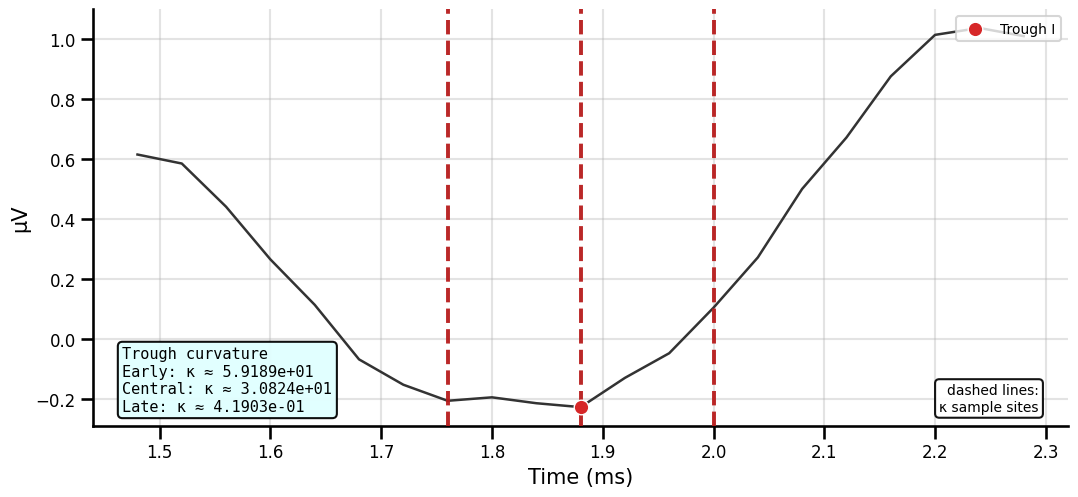

In [16]:
tr_i = int(troughs[0])
curv_tr = np.asarray(fe_curvature(wf_full, tr_i)).ravel()

idx_rng = range(tr_i - 10, tr_i + 11)
x_zoom = x_full[list(idx_rng)]
y_zoom = wf_full[list(idx_rng)]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(x_zoom, y_zoom, color="0.2", lw=1.8)
pts_x = x_full[tr_i - 3 : tr_i + 4 : 3]
for tx in pts_x:
    ax.axvline(
        tx,
        ls="--",
        lw=2.8,
        color="#b71c1c",
        alpha=0.95,
        zorder=3,
    )
ax.scatter(
    [x_full[tr_i]],
    [wf_full[tr_i]],
    s=110,
    zorder=6,
    c="C3",
    edgecolors="white",
    linewidths=1,
    label="Trough I",
)

summary_lines = [f"{lb}: κ ≈ {cv:.4e}" for lb, cv in zip(labels, curv_tr)]
summary = "Trough curvature\n" + "\n".join(summary_lines)

ax.text(
    0.03,
    0.03,
    summary,
    transform=ax.transAxes,
    va="bottom",
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="lightcyan", alpha=0.94),
)

ax.text(
    0.97,
    0.03,
    "dashed lines:\nκ sample sites",
    transform=ax.transAxes,
    va="bottom",
    ha="right",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92),
)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("µV")
ax.legend(loc="upper right", fontsize=10)
plot_style(ax)
fig.tight_layout()
fig.savefig(FIG / "feat_trough_curvature.png", dpi=300, bbox_inches="tight")
print("Wrote", (FIG / "feat_trough_curvature.png").resolve())
plt.show()